In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

clean = pd.read_csv("../data/retail_clean.csv", parse_dates=["InvoiceDate"], low_memory=False)
daily = clean.set_index("InvoiceDate")["Revenue"].resample("D").sum().reset_index()
daily.columns = ["ds", "y"]
daily = daily[(daily["y"] > 0) & (daily["ds"] < "2011-12-01")]

# check: which days did the business trade around Christmas?
for y in [2009, 2010]:
    d = daily[(daily["ds"] >= f"{y}-12-20") & (daily["ds"] <= f"{y+1}-01-06")]["ds"].dt.strftime("%b %d").tolist()
    print(y, d)

m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
            daily_seasonality=False, seasonality_mode="multiplicative")
m.fit(daily)
print(len(daily), "training days:", daily["ds"].min().date(), "->", daily["ds"].max().date())

Importing plotly failed. Interactive plots will not work.
d:\PROJECT\retail sales forecasting and customer segmentation project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
02:56:35 - cmdstanpy - INFO - Chain [1] start processing


2009 ['Dec 20', 'Dec 21', 'Dec 22', 'Dec 23', 'Jan 04', 'Jan 05', 'Jan 06']
2010 ['Dec 20', 'Dec 21', 'Dec 22', 'Dec 23', 'Jan 04', 'Jan 05', 'Jan 06']


02:56:35 - cmdstanpy - INFO - Chain [1] done processing


596 training days: 2009-12-01 -> 2011-11-30


In [2]:
future = pd.DataFrame({"ds": pd.date_range("2011-12-01", "2012-05-31")})
fc = m.predict(future)[["ds", "yhat"]]

closed = (fc["ds"].dt.dayofweek == 5) | \
         ((fc["ds"] >= "2011-12-24") & (fc["ds"] <= "2012-01-03"))
fc.loc[closed, "yhat"] = 0
fc["yhat"] = fc["yhat"].clip(lower=0)

prophet_future = fc.set_index("ds")["yhat"].resample("MS").sum()
prophet_future.round(0)

ds
2011-12-01    821339.0
2012-01-01    624098.0
2012-02-01    573171.0
2012-03-01    705913.0
2012-04-01    712954.0
2012-05-01    835770.0
Freq: MS, Name: yhat, dtype: float64

In [3]:
monthly = pd.read_csv("../data/monthly_revenue.csv", parse_dates=["Month"]).set_index("Month")["Revenue"]
seasonal_future = pd.Series([monthly[d - pd.DateOffset(years=1)] for d in prophet_future.index],
                            index=prophet_future.index)

out = pd.DataFrame({"Prophet": prophet_future, "Seasonal_naive": seasonal_future}).round(0)
out.to_csv("../data/forecast_next_6_months.csv")
out

,Prophet,Seasonal_naive
ds,,
2011-12-01,821339.0,789256.0
2012-01-01,624098.0,593256.0
2012-02-01,573171.0,507867.0
2012-03-01,705913.0,690062.0
2012-04-01,712954.0,515500.0
2012-05-01,835770.0,740036.0


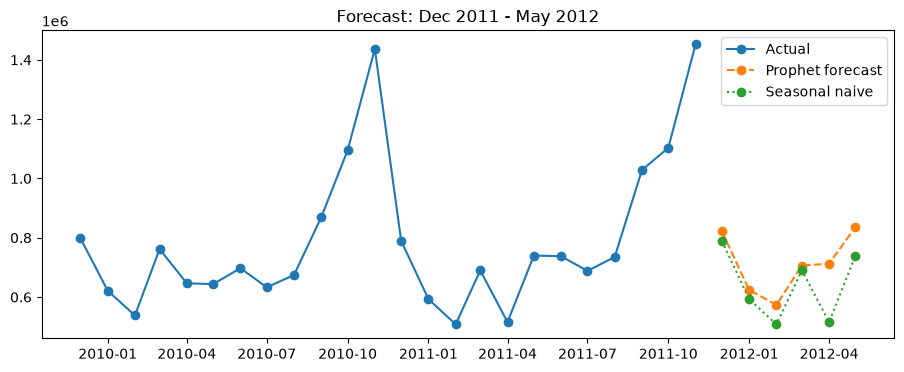

In [4]:
plt.figure(figsize=(11, 4))
plt.plot(monthly.index, monthly, label="Actual", marker="o")
plt.plot(out.index, out["Prophet"], label="Prophet forecast", linestyle="--", marker="o")
plt.plot(out.index, out["Seasonal_naive"], label="Seasonal naive", linestyle=":", marker="o")
plt.legend()
plt.title("Forecast: Dec 2011 - May 2012")
plt.show()